# A partir de Victor

## Con keras (funciones de victor)

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking, Bidirectional, Dropout, Masking
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
import numpy as np

# 1. Cargar datos (Asegúrate de que las rutas sean correctas)
X_correct_mirrored = np.load('../Data/Processed/mirrored_correct_push_ups_landmarks.npy')
X_incorrect_mirrored = np.load('../Data/Processed/mirrored_wrong_push_ups_landmarks.npy')
X_correct_original = np.load('../Data/Processed/correct_push_ups_landmarks.npy')
X_incorrect_original = np.load('../Data/Processed/wrong_push_ups_landmarks.npy')

# 2. Concatenar clases para formar X e y (Mirrored y Original por separado primero)
# MIRRORED
X_mirrored = np.vstack((X_correct_mirrored, X_incorrect_mirrored))
y_mirrored = np.array([1]*len(X_correct_mirrored) + [0]*len(X_incorrect_mirrored))

# ORIGINAL
X_original = np.vstack((X_correct_original, X_incorrect_original))
y_original = np.array([1]*len(X_correct_original) + [0]*len(X_incorrect_original))

# 3. CREACIÓN DE LOS GRUPOS (La parte clave)
# Asumimos que el video i-ésimo de X_original corresponde al video i-ésimo de X_mirrored
# Creamos un ID único para cada video original
original_ids = np.arange(len(X_original))
mirrored_ids = np.arange(len(X_mirrored)) # Debería ser igual al anterior si están ordenados

# 4. JUNTAR TODO (Original + Mirrored)
X_total = np.concatenate((X_original, X_mirrored), axis=0)
y_total = np.concatenate((y_original, y_mirrored), axis=0)

# El array 'groups' le dice al KFold qué filas son "hermanas"
groups = np.concatenate((original_ids, mirrored_ids), axis=0) # evita fugas de datos, usa el mismo video original y espejado en el mismo conjunto (no el original en train y el espejado en val por ejemplo)

print(f"Forma de X_total: {X_total.shape}")
print(f"Forma de y_total: {y_total.shape}")
print(f"Forma de groups: {groups.shape}")
print(f"Ejemplo: El dato en índice 0 (orig) y el índice {len(X_original)} (mirror) tienen el grupo {groups[0]} y {groups[len(X_original)]}")

Forma de X_total: (200, 160, 66)
Forma de y_total: (200,)
Forma de groups: (200,)
Ejemplo: El dato en índice 0 (orig) y el índice 100 (mirror) tienen el grupo 0 y 0


In [3]:
import numpy as np
from sklearn.model_selection import KFold, GroupKFold
from tensorflow.keras.callbacks import EarlyStopping

# ==============================================================================
# 1. GESTOR DE UN SOLO PLIEGUE (FOLD MANAGER)
# ==============================================================================
def train_single_fold(model_fn, X_train_f, y_train_f, X_val_f, y_val_f, 
                      timesteps, features, epochs, batch_size, patience, fold_n):
    """
    Se encarga de crear, entrenar, evaluar y predecir para UN solo pliegue.
    """
    
    # A. Configurar Callbacks
    callbacks_list = []
    if patience is not None and patience > 0:
        early_stopping = EarlyStopping(
            monitor='val_loss', 
            patience=patience, 
            restore_best_weights=True,
            verbose=0
        )
        callbacks_list.append(early_stopping)

    # B. Instanciar Modelo (Limpio)
    model = model_fn(timesteps, features) 
    
    # C. Entrenar
    # Keras maneja el bucle de épocas internamente
    history = model.fit(
        X_train_f, y_train_f,
        validation_data=(X_val_f, y_val_f),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks_list,
        verbose=0 # Silencioso para no saturar la consola
    )
    
    # D. Evaluar Métricas
    loss, acc = model.evaluate(X_val_f, y_val_f, verbose=0)
    
    # E. Generar Predicciones (Inferencia)
    y_pred_prob = model.predict(X_val_f, verbose=0)
    
    # Conversión Probabilidad -> Clase
    if y_pred_prob.shape[-1] == 1:
        # Caso Binario Sigmoid
        y_pred_class = (y_pred_prob > 0.5).astype(int).flatten()
    else:
        # Caso Softmax
        y_pred_class = np.argmax(y_pred_prob, axis=-1)
        
    return acc, loss, history.history, y_pred_class

# ==============================================================================
# 2. ORQUESTADOR PRINCIPAL (GROUP K-FOLD)
# ==============================================================================
def run_kfold_experiment(model_fn, X_train, y_train, groups,
                                     epochs, batch_size, n_splits=5, patience=None):
    """
    Orquesta el GroupKFold para evitar Data Leakage con datos aumentados.
    
    Args:
        groups (np.array): Array de IDs que vincula muestras originales con sus aumentaciones.
    """
    
    # Usamos GroupKFold en lugar de KFold estándar
    gkf = GroupKFold(n_splits=n_splits)
    
    # Acumuladores
    fold_accuracies = []
    fold_histories = []
    
    # Listas para reordenamiento
    global_y_true_unsorted = []
    global_y_pred_unsorted = []
    global_indices = [] 
    
    print(f"🚀 Iniciando GroupKFold Keras ({n_splits} splits)...")
    print(f"   Protección contra Data Leakage activa (Grupos detectados: {len(np.unique(groups))})")
    print("===" * 20)
    
    _, timesteps, features = X_train.shape

    # PASAMOS 'groups' AL SPLIT
    for fold_idx, (train_index, val_index) in enumerate(gkf.split(X_train, y_train, groups=groups)):
        print(f"\n🔄 Pliegue {fold_idx + 1}/{n_splits}")

        # A. Preparar Datos
        X_train_f, X_val_f = X_train[train_index], X_train[val_index]
        y_train_f, y_val_f = y_train[train_index], y_train[val_index]

        # B. Delegar trabajo al Fold Manager (train_single_fold)
        # Nota: train_single_fold es idéntica a la versión anterior
        acc, loss, history, fold_preds = train_single_fold(
            model_fn, X_train_f, y_train_f, X_val_f, y_val_f,
            timesteps, features, epochs, batch_size, patience, fold_idx+1
        )
        
        print(f"    ✅ Fin Fold {fold_idx+1}. Acc Val: {acc:.4f} | Loss: {loss:.4f}")
        
        # C. Recolectar resultados
        fold_accuracies.append(acc)
        fold_histories.append(history)
        
        global_y_true_unsorted.extend(y_val_f)
        global_y_pred_unsorted.extend(fold_preds)
        global_indices.extend(val_index)

    # 3. REORDENAMIENTO FINAL
    global_indices_np = np.array(global_indices)
    sorted_order = np.argsort(global_indices_np)
    
    final_y_true = np.array(global_y_true_unsorted)[sorted_order]
    final_y_pred = np.array(global_y_pred_unsorted)[sorted_order]
    
    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)

    print("===" * 20)
    print(f"📊 Resultados GroupKFold:")
    print(f"| Accuracy Medio: {mean_acc:.4f}")
    print(f"| Desviación Std: {std_acc:.4f}")
    
    return mean_acc, std_acc, fold_histories, final_y_true, final_y_pred

In [4]:
def create_lstm_model(timesteps, features):
    # Aquí puedes modificar 128 a 32, cambiar el recurrent_dropout, etc.
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    model.add(LSTM(128, return_sequences=False)) 
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))

    custom_adam = Adam(learning_rate=0.0001) # <-- Nueva Tasa de Aprendizaje

    # Compilamos el modelo
    model.compile(
        loss='binary_crossentropy',
        optimizer=custom_adam,
        metrics=['accuracy']
    )

    return model

In [5]:
# Definimos parámetros
TIMESTEPS = X_total.shape[1]
FEATURES = X_total.shape[2]
EPOCHS = 40       # Ajusta según necesites
BATCH_SIZE = 16
PATIENCE = 10     # Para el Early Stopping

# Ejecutamos el experimento
mean_acc, std_acc, histories, final_y_true, final_y_pred = run_kfold_experiment(
    model_fn=create_lstm_model,  # <--- AQUÍ VA TU FUNCIÓN QUE CREA LA LSTM
    X_train=X_total, # pasamos el conjunto total ya que la división la hace internamente GroupKFold en run_kfold_experiment
    y_train=y_total,
    groups=groups,               # <--- AQUÍ PASAMOS LOS GRUPOS PARA EVITAR EL LEAKAGE
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    n_splits=5,
    patience=PATIENCE
)

🚀 Iniciando GroupKFold Keras (5 splits)...
   Protección contra Data Leakage activa (Grupos detectados: 100)

🔄 Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    ✅ Fin Fold 1. Acc Val: 0.8500 | Loss: 0.3785

🔄 Pliegue 2/5
    ✅ Fin Fold 2. Acc Val: 0.8250 | Loss: 0.3689

🔄 Pliegue 3/5
    ✅ Fin Fold 3. Acc Val: 0.8750 | Loss: 0.3842

🔄 Pliegue 4/5
    ✅ Fin Fold 4. Acc Val: 0.8000 | Loss: 0.4654

🔄 Pliegue 5/5
    ✅ Fin Fold 5. Acc Val: 0.9250 | Loss: 0.3446
📊 Resultados GroupKFold:
| Accuracy Medio: 0.8550
| Desviación Std: 0.0430


## Evaluamos

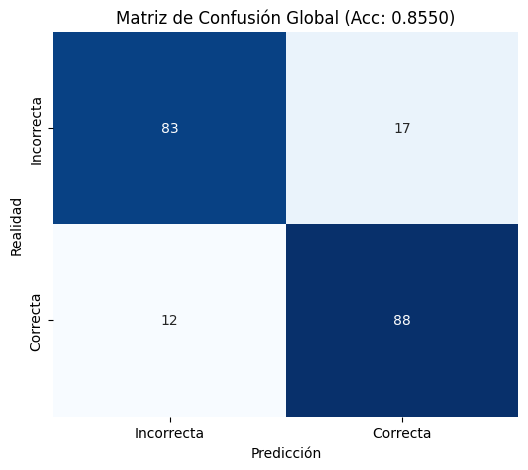


📋 Reporte de Clasificación:
              precision    recall  f1-score   support

  Incorrecta       0.87      0.83      0.85       100
    Correcta       0.84      0.88      0.86       100

    accuracy                           0.85       200
   macro avg       0.86      0.85      0.85       200
weighted avg       0.86      0.85      0.85       200



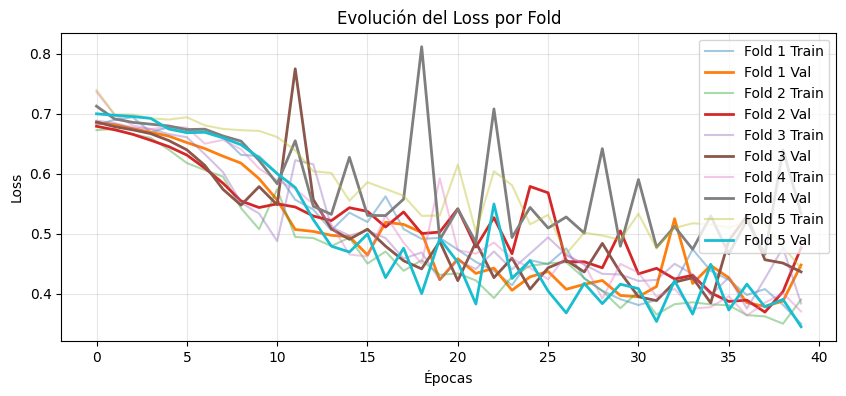

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. MATRIZ DE CONFUSIÓN
cm = confusion_matrix(final_y_true, final_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Incorrecta', 'Correcta'],
            yticklabels=['Incorrecta', 'Correcta'])
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title(f'Matriz de Confusión Global (Acc: {mean_acc:.4f})')
plt.show()

# 2. REPORTE DE CLASIFICACIÓN
print("\n📋 Reporte de Clasificación:")
print(classification_report(final_y_true, final_y_pred, target_names=['Incorrecta', 'Correcta']))

# 3. CURVAS DE APRENDIZAJE (LOSS)
plt.figure(figsize=(10, 4))
for i, h in enumerate(histories):
    plt.plot(h['loss'], label=f'Fold {i+1} Train', alpha=0.4)
    plt.plot(h['val_loss'], label=f'Fold {i+1} Val', linewidth=2)

plt.title('Evolución del Loss por Fold')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Experimentos 

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking, Dropout
from tensorflow.keras.optimizers import Adam

def create_tunable_lstm(timesteps, features, units=128, dropout_rate=0.2, learning_rate=0.001):
    """
    Crea un modelo LSTM con parámetros configurables.
    """
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    
    # LSTM con unidades variables
    model.add(LSTM(units, return_sequences=False))
    model.add(Dropout(dropout_rate)) # Dropout variable
    
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(dropout_rate)) # Dropout variable

    model.add(Dense(1, activation='sigmoid'))
    
    # Optimizador con Learning Rate variable
    optimizer = Adam(learning_rate=learning_rate)
    
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

In [8]:
import pandas as pd

# --- A. DEFINIR LOS EXPERIMENTOS ---
experiments_config = [
    # Exp 1: Modelo sencillo (rápido)
    {'name': 'LSTM_Simple', 'units': 64, 'dropout': 0.1, 'lr': 0.001},
    
    # Exp 2: Modelo estándar (el que tenías)
    {'name': 'LSTM_Standard', 'units': 128, 'dropout': 0.2, 'lr': 0.0001},
    
    # Exp 3: Modelo complejo (más capacidad)
    {'name': 'LSTM_Complex', 'units': 256, 'dropout': 0.3, 'lr': 0.00005}
]

results_table = []

print(f"🧪 INICIANDO BATERÍA DE {len(experiments_config)} EXPERIMENTOS...")
print("="*60)

# --- B. BUCLE DE EJECUCIÓN ---
for config in experiments_config:
    print(f"\n▶️ Ejecutando: {config['name']}")
    print(f"   Config: Units={config['units']}, Drop={config['dropout']}, LR={config['lr']}")
    
    # TRUCO: Usamos lambda para 'congelar' los parámetros de configuración
    # y pasarle a run_kfold_experiment una función que solo pide (timesteps, features)
    model_builder = lambda t, f: create_tunable_lstm(
        t, f, 
        units=config['units'], 
        dropout_rate=config['dropout'], 
        learning_rate=config['lr']
    )
    
    # Llamamos a TU función de GroupKFold
    mean_acc, std_acc, _, _, _ = run_kfold_experiment(
        model_fn=model_builder,
        X_train=X_total,
        y_train=y_total,
        groups=groups,
        epochs=40,        # Puedes bajarlo a 20 para pruebas rápidas
        batch_size=16,
        n_splits=5,
        patience=10
    )
    
    # Guardamos resultados
    results_table.append({
        'Modelo': config['name'],
        'Accuracy': mean_acc,
        'Std (+/-)': std_acc,
        'Units': config['units'],
        'LR': config['lr']
    })

print("\n✅ ¡Todos los experimentos finalizados!")

🧪 INICIANDO BATERÍA DE 3 EXPERIMENTOS...

▶️ Ejecutando: LSTM_Simple
   Config: Units=64, Drop=0.1, LR=0.001
🚀 Iniciando GroupKFold Keras (5 splits)...
   Protección contra Data Leakage activa (Grupos detectados: 100)

🔄 Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    ✅ Fin Fold 1. Acc Val: 0.8500 | Loss: 0.3729

🔄 Pliegue 2/5
    ✅ Fin Fold 2. Acc Val: 0.7750 | Loss: 0.4908

🔄 Pliegue 3/5
    ✅ Fin Fold 3. Acc Val: 0.8750 | Loss: 0.5073

🔄 Pliegue 4/5
    ✅ Fin Fold 4. Acc Val: 0.7750 | Loss: 0.4676

🔄 Pliegue 5/5
    ✅ Fin Fold 5. Acc Val: 0.8500 | Loss: 0.3977
📊 Resultados GroupKFold:
| Accuracy Medio: 0.8250
| Desviación Std: 0.0418

▶️ Ejecutando: LSTM_Standard
   Config: Units=128, Drop=0.2, LR=0.0001
🚀 Iniciando GroupKFold Keras (5 splits)...
   Protección contra Data Leakage activa (Grupos detectados: 100)

🔄 Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    ✅ Fin Fold 1. Acc Val: 0.8500 | Loss: 0.4023

🔄 Pliegue 2/5
    ✅ Fin Fold 2. Acc Val: 0.8250 | Loss: 0.4575

🔄 Pliegue 3/5
    ✅ Fin Fold 3. Acc Val: 0.8250 | Loss: 0.3414

🔄 Pliegue 4/5
    ✅ Fin Fold 4. Acc Val: 0.8000 | Loss: 0.4895

🔄 Pliegue 5/5
    ✅ Fin Fold 5. Acc Val: 0.9000 | Loss: 0.2584
📊 Resultados GroupKFold:
| Accuracy Medio: 0.8400
| Desviación Std: 0.0339

▶️ Ejecutando: LSTM_Complex
   Config: Units=256, Drop=0.3, LR=5e-05
🚀 Iniciando GroupKFold Keras (5 splits)...
   Protección contra Data Leakage activa (Grupos detectados: 100)

🔄 Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    ✅ Fin Fold 1. Acc Val: 0.8500 | Loss: 0.3986

🔄 Pliegue 2/5
    ✅ Fin Fold 2. Acc Val: 0.8250 | Loss: 0.4516

🔄 Pliegue 3/5
    ✅ Fin Fold 3. Acc Val: 0.8500 | Loss: 0.4151

🔄 Pliegue 4/5
    ✅ Fin Fold 4. Acc Val: 0.7750 | Loss: 0.4902

🔄 Pliegue 5/5
    ✅ Fin Fold 5. Acc Val: 0.9000 | Loss: 0.3265
📊 Resultados GroupKFold:
| Accuracy Medio: 0.8400
| Desviación Std: 0.0406

✅ ¡Todos los experimentos finalizados!



🏆 TABLA DE RESULTADOS:


,Modelo,Accuracy,Std (+/-),Units,LR
1,LSTM_Standard,0.840,0.033912,128,0.00010
2,LSTM_Complex,0.840,0.040620,256,0.00005
0,LSTM_Simple,0.825,0.041833,64,0.00100


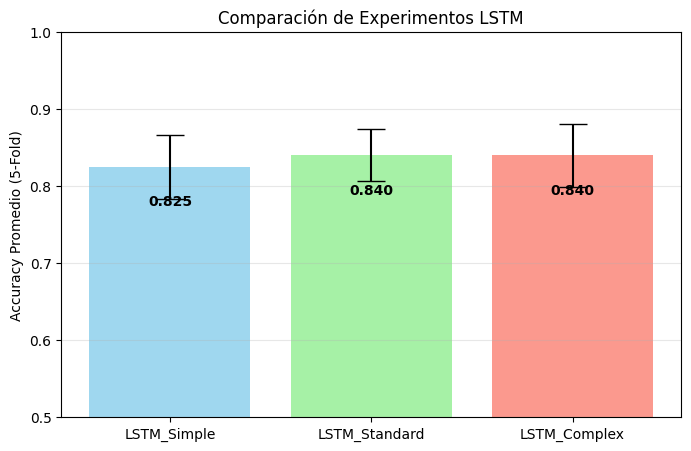

In [9]:
# Convertir a DataFrame para ver bonito
df_results = pd.DataFrame(results_table)

# Mostrar tabla ordenada por mejor resultado
print("\n🏆 TABLA DE RESULTADOS:")
display(df_results.sort_values(by='Accuracy', ascending=False))

# Gráfico de Barras Comparativo
plt.figure(figsize=(8, 5))
# Barras con barras de error (std)
plt.bar(df_results['Modelo'], df_results['Accuracy'], yerr=df_results['Std (+/-)'], 
        capsize=10, color=['skyblue', 'lightgreen', 'salmon'], alpha=0.8)

plt.ylim(0.5, 1.0) # Ajustar según tus resultados (ej. de 0.5 a 1.0)
plt.ylabel('Accuracy Promedio (5-Fold)')
plt.title('Comparación de Experimentos LSTM')
plt.grid(axis='y', alpha=0.3)

# Añadir etiquetas de valor encima de las barras
for i, row in df_results.iterrows():
    plt.text(i, row['Accuracy'] - 0.05, f"{row['Accuracy']:.3f}", 
             ha='center', color='black', fontweight='bold')

plt.show()